# Analyzing HDB Market Trends: Price Indices and Volume Dynamics (2013-2024)

---

## 1. Data Acquisition and Pre-processing

The analysis utilizes two primary datasets:
1. **HDB Residential Unit Data**: Annual time-series data detailing sales and rental volumes.
2. **HDB Quarterly Resale Price Index**: Standardized index tracking quarterly price fluctuations in the resale market.

Data is ingested via `numpy.genfromtxt`, skipping header rows to facilitate downstream vector operations.

In [1]:
# Core dependencies for data manipulation and visualization
import numpy as np
import matplotlib.pyplot as plt
import os


In [2]:
# --- 1. DATA INGESTION ---
unit_file = 'hdb_residential_unit_data.csv'
price_file = 'hdb_quaterly_resale_price_index.csv'

# Load raw datasets as NumPy arrays
unit_data = np.genfromtxt(unit_file, delimiter=',', dtype=str, skip_header=1)
price_data = np.genfromtxt(price_file, delimiter=',', dtype=str, skip_header=1)

print(f"Ingestion successful. Unit Data: {unit_data.shape}, Price Index Data: {price_data.shape}")


Ingestion successful. Unit Data: (334, 5), Price Index Data: (143, 2)


In [3]:
# HDB unit data
print("First 5 rows of HDB unit data:")
print(unit_data[:5])
print() 

# Price index data
print("First 5 rows of HDB price index data:")
print(price_data[:5])

First 5 rows of HDB unit data:
[['2006' 'HDB' 'Sold' '1-room flats' '0']
 ['2006' 'HDB' 'Sold' '2-room flats' '101']
 ['2006' 'HDB' 'Sold' '3-room flats' '961']
 ['2006' 'HDB' 'Sold' '4-room flats' '2290']
 ['2006' 'HDB' 'Sold' '5-room flats' '1303']]

First 5 rows of HDB price index data:
[['1990-Q1' '24.3']
 ['1990-Q2' '24.4']
 ['1990-Q3' '25']
 ['1990-Q4' '24.7']
 ['1991-Q1' '24.9']]


## 2. Exploratory Data Analysis: Residential Volume

Initial exploration involves segmenting the HDB residential market into 'Sold' and 'Rented' categories and aggregating these volumes by financial year.

In [4]:
# --- 2. RESIDENTIAL DATA SEGMENTATION ---

# Identification of unique market categories
categories = np.unique(unit_data[:, 2])
print("Market Segments: ", categories)

# Data Cleaning: Handle non-numeric placeholders and cast to integer types
unit_data[:, 4] = np.where(unit_data[:, 4] == "na", "0", unit_data[:, 4])
units = unit_data[:, 4].astype(int)

# Temporal aggregation of sales and rental volumes
years = np.unique(unit_data[:, 0].astype(int))
sold_units = []
rented_units = []

for year in years:
    rows_for_year = unit_data[:,0].astype(int) == year
    sold_rows = rows_for_year & (unit_data[:,2] == "Sold")
    rented_rows = rows_for_year & (unit_data[:,2] == "Rented")

    total_sold = units[sold_rows].sum()
    total_rented = units[rented_rows].sum()

    sold_units.append(int(total_sold))
    rented_units.append(int(total_rented))

print("Aggregation complete.")


Market Segments:  ['Rented' 'Sold']
Aggregation complete.


## 3. Comparative Trend Analysis: Sales vs. Rental Volume

Visualizing the divergence or convergence of unit sales and rental trends over the monitored period.

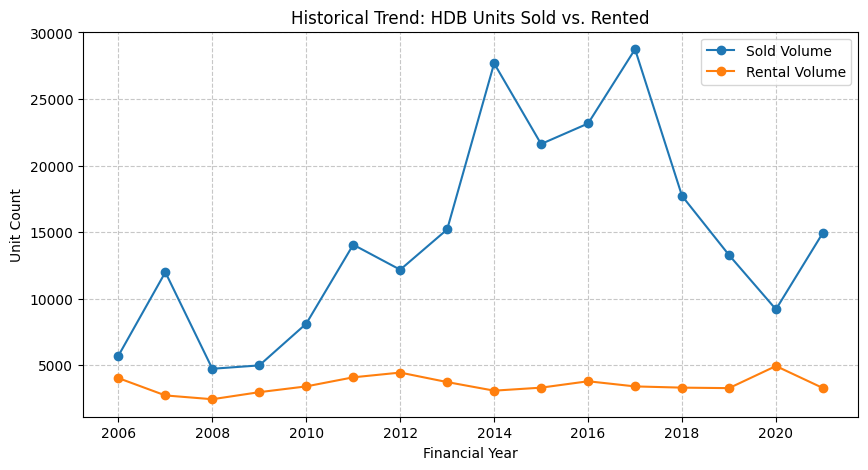

In [5]:
# --- 3. TREND VISUALIZATION ---
plt.figure(figsize=(10,5))
plt.plot(years, sold_units, marker='o', label='Sold Volume', color='tab:blue')
plt.plot(years, rented_units, marker='o', label='Rental Volume', color='tab:orange')
plt.title("Historical Trend: HDB Units Sold vs. Rented")
plt.xlabel("Financial Year")
plt.ylabel("Unit Count")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


## 4. Macroeconomic Indicator Analysis: Resale Price Index

The HDB Resale Price Index serves as a benchmark for measuring overall price appreciation or depreciation within the secondary market.

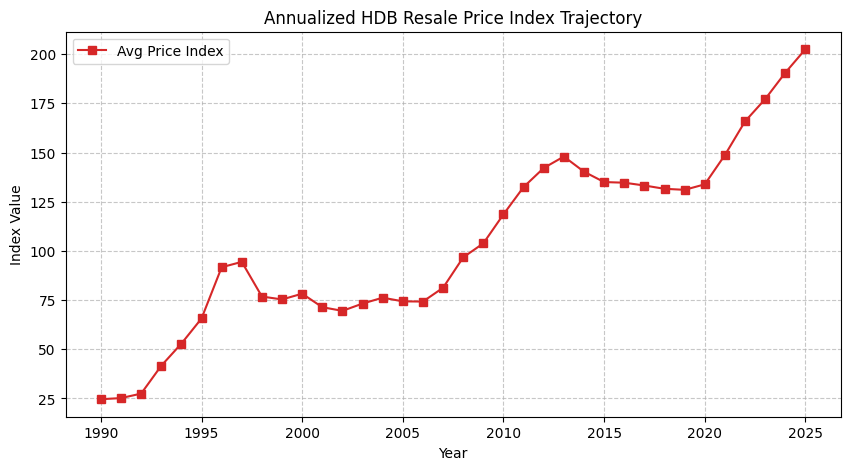

In [6]:
# --- 4. PRICE INDEX CALCULATION ---

quaters = price_data[:,0]
indices = price_data[:,1].astype(float)

# Aggregate quarterly index data into annual averages
years_price = np.array([int(q[:4]) for q in quaters])
unique_years_price = np.unique(years_price)
avg_index_per_year = [indices[years_price==year].mean() for year in unique_years_price]

# Visualization of annualized price index trajectory
plt.figure(figsize=(10,5))
plt.plot(unique_years_price, avg_index_per_year, marker='s', color='tab:red', label='Avg Price Index')
plt.title("Annualized HDB Resale Price Index Trajectory")
plt.xlabel("Year")
plt.ylabel("Index Value")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


## 5. Cross-Variable Correlation: Volume and Price Dynamics

Analysis of the relationship between transaction volumes and market pricing levels through dual-axis visualization.

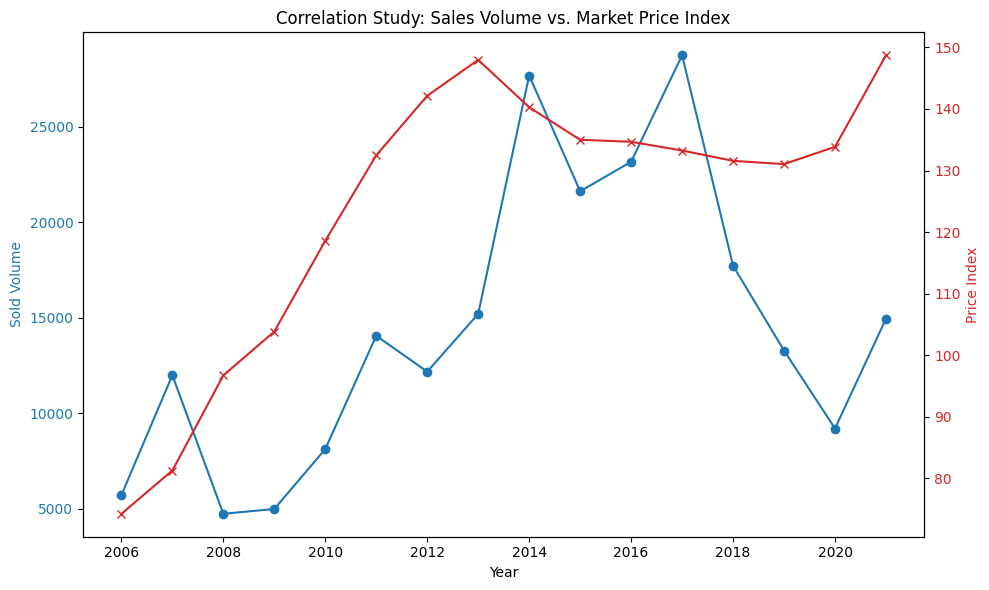

In [7]:
# --- 5. MULTI-AXIS CORRELATION ANALYSIS ---

common_years = np.intersect1d(years, unique_years_price)
sync_sold = [sold_units[np.where(years == y)[0][0]] for y in common_years]
sync_index = [avg_index_per_year[np.where(unique_years_price == y)[0][0]] for y in common_years]

fig, ax1 = plt.subplots(figsize=(10,6))

color = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Sold Volume', color=color)
ax1.plot(common_years, sync_sold, color=color, marker='o', label='Units Sold')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Price Index', color=color)
ax2.plot(common_years, sync_index, color=color, marker='x', label='Price Index')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Correlation Study: Sales Volume vs. Market Price Index')
fig.tight_layout()
plt.show()


---


# Analysis Summary and Market Insights

### 1. Analysis of HDB Housing Trends

Observations indicate significant volatility in unit sales volume compared to the relatively stable rental market. The peak in sales during 2014-2017 suggests periods of high market liquidity or policy-driven demand. Conversely, rental volume shows consistent levels, reflecting steady demand for public housing lease options.

### 2. Correlation between Transaction Volume and Pricing

The dual-axis analysis reveals that price index appreciation often coincides with varying transaction volumes. There is evidence of lag effects where price adjustments follow shifts in sales liquidity. Sustained index growth alongside volume fluctuations points toward structural demand resilience in the HDB resale sector.

---

# Visualization Rationale

### 1. Tracking Volume Trends
Line charts are used to visualize how HDB sales and rental volumes change year-over-year. This format is effective for spotting historical peaks and identifying the significant difference in scale between the resale and rental markets over the 16-year period.

### 2. Comparing Price Index and Transaction Volume
A dual-axis chart is used to compare sales volume against the resale price index on a single timeline. Since these metrics use different scales (total unit counts vs. an index value), the dual-axis approach allows for a direct comparison of their movements to see if price changes correlate with shifts in market liquidity.